## Regression MLP 
Let's load split and scale the California housing dataset

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

housing = fetch_california_housing()

x_train_full, x_test, y_train_full, y_test = train_test_split(
    housing.data,
    housing.target,
    random_state = 42)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full, random_state = 42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

In [2]:
import numpy as np
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
from tensorflow import keras
model = keras.models.Sequential([
    keras.layers.Input(shape=x_train.shape[1:]),
    keras.layers.Dense(30, activation='relu'), 
    keras.layers.Dense(1)
])

model.compile(loss="mean_squared_error",
             optimizer = keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)
x_new = x_test[:3]
y_pred = model.predict(x_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.1913 - val_loss: 1.7166
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8122 - val_loss: 0.7691
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7166 - val_loss: 0.6872
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6683 - val_loss: 0.6444
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 0.6275 - val_loss: 0.6050
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - loss: 0.5915 - val_loss: 0.5688
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5602 - val_loss: 0.5364
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5335 - val_loss: 0.5088
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5116 - val_loss: 0.4855
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4938 - val_loss: 0.4664
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4794 - val_loss: 0.4510
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

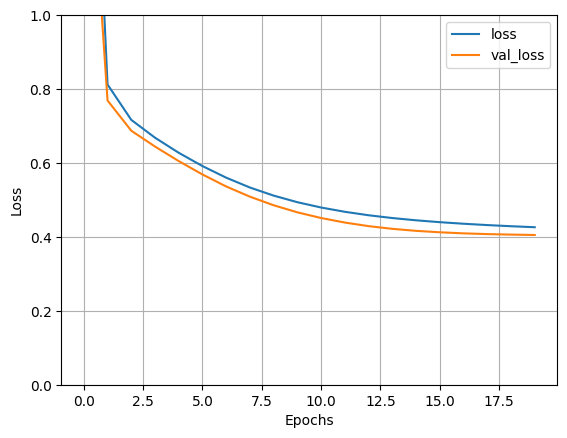

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.gca().set_ylim(0, 1)
plt.grid(True)

In [5]:
y_pred

array([[0.76816833],
       [1.7155199 ],
       [3.3824847 ]], dtype=float32)

## Functional API
Not all neural network models are simply sequential. Some may have complex topologies. Some may have multiple inputs and/or multiple outputs. For example, a Wide & Deep neural network (see paper) connects all or part of the inputs directly to the output layer.

In [6]:
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
input_ = keras.layers.Input(shape=x_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 30)                │             270 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 30)                │             930 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 38)                │               0 │ input_layer_1[0][0],       │
│                               │                           │                 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 1)                 │              39 │ concatenate[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(x_train, x_train, epochs=20,
                    validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)
y_pred = model.predict(x_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9889 - val_loss: 7.9751
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9084 - val_loss: 6.8405
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9017 - val_loss: 7.0620
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9004 - val_loss: 7.0077
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8998 - val_loss: 7.0186
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8993 - val_loss: 7.0159
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8989 - val_loss: 7.0162
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8985 - val_loss: 7.0156
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8982 - val_loss: 7.0155
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8979 - val_loss: 7.0153
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8977 - val_loss: 7.0154
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [9]:
y_pred

array([[-0.1529384 ],
       [-0.14480752],
       [-0.05599098]], dtype=float32)

What if you want to send different subsets of input features through the wide or deep paths? We will send 5 features (features 0 to 4), and 6 through the deep path (features 2 to 7). Note that 3 features will go through both (features 2, 3 and 4).

In [10]:
np.random.seed(42)
tf.random.set_seed(42)

In [11]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.models.Model(inputs=[input_A, input_B], outputs=[output])

In [12]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

x_train_A, x_train_B = x_train[:, :5], x_train[:, 2:]
x_valid_A, x_valid_B = x_valid[:, :5], x_valid[:, 2:]
x_test_A, x_test_B = x_test[:, :5], x_test[:, 2:]
x_new_A, x_new_B = x_test_A[:3], x_test_B[:3]

history = model.fit((x_train_A, x_train_B), y_train, epochs=20,
                   validation_data=((x_valid_A, x_valid_B), y_valid))
msE_test = model.evaluate((x_test_A, x_test_B), y_test)
y_pred = model.predict((x_new_A, x_new_B))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2318 - val_loss: 1.0462
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8014 - val_loss: 0.8143
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6465 - val_loss: 0.5858
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5870 - val_loss: 0.5612
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5506 - val_loss: 0.5186
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5247 - val_loss: 0.4999
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5049 - val_loss: 0.4809
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4894 - val_loss: 0.4679
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4770 - val_loss: 0.4561
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4669 - val_loss: 0.4472
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4587 - val_loss: 0.4396
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Adding an auxiliary output for regularization:

In [13]:
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.models.Model(inputs=[input_A, input_B],
                           outputs=[output, aux_output])

In [15]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit([x_train_A, x_train_B], [y_train, y_train], epochs=20,
                    validation_data=([x_valid_A, x_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 3.9693 - loss: 2.2493 - main_output_loss: 2.0577 - val_aux_output_loss: 6.8469 - val_loss: 2.1427 - val_main_output_loss: 1.6193
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - aux_output_loss: 2.4074 - loss: 1.0260 - main_output_loss: 0.8725 - val_aux_output_loss: 6.1311 - val_loss: 1.3865 - val_main_output_loss: 0.8588
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_loss: 1.8697 - loss: 0.8495 - main_output_loss: 0.7362 - val_aux_output_loss: 5.2348 - val_loss: 1.1311 - val_main_output_loss: 0.6747
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_loss: 1.6288 - loss: 0.7591 - main_output_loss: 0.6626 - val_aux_output_loss: 4.3655 - val_loss: 0.9891 - val_main_output_loss: 0.6136
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - aux_output_loss: 1.4894 - loss: 0.7007 - main_output_loss: 0.6132 - val_aux_output_loss: 3.5831 - val_loss: 0.8788 - val_main_output_loss: 0.5780


In [16]:
total_loss, main_loss, aux_loss = model.evaluate(
    [x_test_A, x_test_B], [y_test, y_test])
y_pred_main, y_pred_aux = model.predict([x_new_A, x_new_B])

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - aux_output_loss: 0.8738 - loss: 0.4746 - main_output_loss: 0.4308 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


## The subclassing API

In [17]:
class WideAndDeepModel(keras.models.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel(30, activation="relu")

In [18]:
x_train_A = np.array(x_train_A)
x_train_B = np.array(x_train_B)
x_valid_A = np.array(x_valid_A)
x_valid_B = np.array(x_valid_B)
x_test_A  = np.array(x_test_A)
x_test_B  = np.array(x_test_B)

y_train = np.array(y_train)
y_valid = np.array(y_valid)
y_test  = np.array(y_test)

model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1],
              optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit((x_train_A, x_train_B), (y_train, y_train), epochs=10,
                   validation_data=((x_valid_A, x_valid_B), (y_valid, y_valid)))
total_loss, main_loss, aux_loss = model.evaluate((x_test_A, x_test_B), (y_test, y_test))
y_pred_main, y_pred_aux = model.predict((x_test_A, x_test_B))

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.1198 - mse_loss: 4.8615 - val_loss: 1.4448 - val_mse_loss: 5.4645
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9930 - mse_loss: 3.1513 - val_loss: 1.1486 - val_mse_loss: 4.9848
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8098 - mse_loss: 2.2464 - val_loss: 0.9954 - val_mse_loss: 4.4125
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7233 - mse_loss: 1.8204 - val_loss: 0.8804 - val_mse_loss: 3.7044
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6737 - mse_loss: 1.6030 - val_loss: 0.7848 - val_mse_loss: 3.0243
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6399 - mse_loss: 1.4739 - val_loss: 0.7154 - val_mse_loss: 2.5402
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6142 - mse_loss: 1.3858 - val_loss: 0.6691 - val_mse_loss: 2.2510
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5936 - mse_loss: 1.3204 - val_loss: 0.6315

## Saving and Restoring

In [19]:
np.random.seed(42)
tf.random.set_seed(42)

In [20]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_valid, y_valid))
mse_test = model.evaluate(x_test, y_test)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.1034 - val_loss: 1.1181
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7571 - val_loss: 0.6423
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6359 - val_loss: 0.5831
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5938 - val_loss: 0.5525
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5620 - val_loss: 0.5309
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5351 - val_loss: 0.5134
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5116 - val_loss: 0.4998
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4912 - val_loss: 0.4907
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4739 - val_loss: 0.4851
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4592 - val_loss: 0.4823
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.4449


In [21]:
model.save("my_keras_model.keras")  
model = keras.models.load_model("my_keras_model.keras")

In [22]:
X_new = np.array(x_new)
y_pred = model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0.6488181],
       [1.3499997],
       [3.076454 ]], dtype=float32)

In [23]:
model.save_weights("my_keras_weights.weights.h5")
model.load_weights("my_keras_weights.weights.h5")

## Using Callbacks during Training

In [24]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

In [25]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.keras", save_best_only=True)

history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.keras") # rollback to best model
mse_test = model.evaluate(x_test, y_test)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.9572 - val_loss: 1.2054
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8080 - val_loss: 0.6939
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6794 - val_loss: 0.6608
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6275 - val_loss: 0.6283
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5861 - val_loss: 0.5880
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5502 - val_loss: 0.5450
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5187 - val_loss: 0.5049
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4915 - val_loss: 0.4699
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4690 - val_loss: 0.4422
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4512 - val_loss: 0.4214
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - loss: 0.4396


In [26]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=100,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb])
mse_test = model.evaluate(x_test, y_test)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4373 - val_loss: 0.4060
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4265 - val_loss: 0.3945
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4179 - val_loss: 0.3864
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4109 - val_loss: 0.3806
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4052 - val_loss: 0.3764
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4004 - val_loss: 0.3732
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3963 - val_loss: 0.3708
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3927 - val_loss: 0.3689
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3895 - val_loss: 0.3670
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3868 - val_loss: 0.3647
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3843 - val_loss: 0.3626
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

In [27]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

In [28]:
val_train_ratio_cb = PrintValTrainRatioCallback()
history = model.fit(x_train, y_train, epochs=1,
                    validation_data=(x_valid, y_valid),
                    callbacks=[val_train_ratio_cb])

318/363 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - loss: 0.3385
val/train: 0.97
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3244 - val_loss: 0.3136


## TensorBoard

In [29]:
import os
root_logdir = os.path.join(os.curdir,  "my_logs")
print(root_logdir)

.\my_logs


In [30]:
def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d_%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
run_logdir

'.\\my_logs\\run_2025_12_20_18_17_51'

In [31]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [32]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [33]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(x_train, y_train, epochs=30,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2218 - val_loss: 1.3128
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8143 - val_loss: 0.7124
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7107 - val_loss: 0.6503
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6667 - val_loss: 0.6130
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6321 - val_loss: 0.5816
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6018 - val_loss: 0.5532
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5749 - val_loss: 0.5287
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5508 - val_loss: 0.5053
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5294 - val_loss: 0.4852
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5105 - val_loss: 0.4676
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4940 - val_loss: 0.4527
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

To start the TensorBoard server, one option is to open a terminal, if needed activate the virtualenv where you installed TensorBoard, go to this notebook's directory, then type:

$ tensorboard --logdir=./my_logs --port=6006
You can then open your web browser to localhost:6006 and use TensorBoard. Once you are done, press Ctrl-C in the terminal window, this will shutdown the TensorBoard server.

Alternatively, you can load TensorBoard's Jupyter extension and run it like this:

In [34]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006

Reusing TensorBoard on port 6006 (pid 20520), started 19:36:11 ago. (Use '!kill 20520' to kill it.)

In [35]:
run_logdir2 = get_run_logdir()
run_logdir2

'.\\my_logs\\run_2025_12_20_18_18_07'

In [36]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [37]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.05))

In [38]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir2)
history = model.fit(x_train, y_train, epochs=30,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5520 - val_loss: 0.4039
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4706 - val_loss: 7.3928
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5233 - val_loss: 662.2675
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4767 - val_loss: 1.3786
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3729 - val_loss: 0.7936
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3626 - val_loss: 0.3475
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3418 - val_loss: 0.3337
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3324 - val_loss: 0.3201
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3264 - val_loss: 0.7781
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3223 - val_loss: 0.3357
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3237 - val_loss: 1.6946
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/st

In [39]:
help(keras.callbacks.TensorBoard.__init__)

Help on function __init__ in module keras.src.callbacks.tensorboard:

__init__(
    self,
    log_dir='logs',
    histogram_freq=0,
    write_graph=True,
    write_images=False,
    write_steps_per_second=False,
    update_freq='epoch',
    profile_batch=0,
    embeddings_freq=0,
    embeddings_metadata=None
)
    Initialize self.  See help(type(self)) for accurate signature.



##  Hyperparameter Tuning

In [40]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [41]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model= keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

In [42]:
from scikeras.wrappers import KerasRegressor
keras_reg = KerasRegressor(model = build_model)

keras_reg.fit(x_train, y_train, epochs=100,
              validation_data=(x_valid, y_valid),
              callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3525 - val_loss: 39.0344
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9329 - val_loss: 6.6206
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6199 - val_loss: 0.9338
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5209 - val_loss: 0.5584
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4828 - val_loss: 0.4603
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4604 - val_loss: 0.4312
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4458 - val_loss: 0.4194
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4353 - val_loss: 0.4133
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4272 - val_loss: 0.4098
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4205 - val_loss: 0.4067
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4150 - val_loss: 0.4031
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━

,model,<function bui...0010AA3194540>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,None


In [43]:
mse_test = keras_reg.score(x_test, y_test)
mse_test

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step


0.7452772236982703

In [44]:
y_pred = keras_reg.predict(x_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([0.59165514, 1.472432  , 4.224678  ], dtype=float32)

In [45]:
np.random.seed(42)
tf.random.set_seed(42)

In [46]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs = {
    "model__n_hidden": [0, 1, 2, 3],
    "model__n_neurons": np.arange(1, 100).tolist(),
    "model__learning_rate": reciprocal(3e-4, 3e-2),
}

rnd_search_cv = RandomizedSearchCV(
    keras_reg,
    param_distribs,
    n_iter=10,
    cv=3,
    verbose=2
)

rnd_search_cv.fit(
    x_train, y_train,
    validation_data=(x_valid, y_valid),
    callbacks=[keras.callbacks.EarlyStopping(patience=10)]
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.3355 - val_loss: 1.9195
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step
[CV] END model__learning_rate=0.0016834549246003507, model__n_hidden=0, model__n_neurons=15; total time=   0.6s
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.9998 - val_loss: 2.8962
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step
[CV] END model__learning_rate=0.0016834549246003507, model__n_hidden=0, model__n_neurons=15; total time=   0.6s
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.6202 - val_loss: 1.4768
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step
[CV] END model__learning_rate=0.0016834549246003507, model__n_hidden=0, model__n_neurons=15; total time=   0.6s
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8059 - val_loss: 286.4017
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step
[CV] END model__learning_rate=0.008731907739399207, model__n_hidden=0, model__n_neurons=21; total time=   0.6s
242/242 ━━━━━━━━━━

,estimator,KerasRegresso...se epochs=1 )
,param_distributions,"{'model__learning_rate': <scipy.stats....0010AA3232510>, 'model__n_hidden': [0, 1, ...], 'model__n_neurons': [1, 2, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [47]:
rnd_search_cv.best_params_

{'model__learning_rate': np.float64(0.00833909265458004),
 'model__n_hidden': 1,
 'model__n_neurons': 38}

In [48]:
rnd_search_cv.best_score_

np.float64(0.5867647893361572)

In [49]:
rnd_search_cv.best_estimator_

,model,<function bui...0010AA3194540>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,None


In [50]:
rnd_search_cv.score(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step


0.5910076010796863

In [51]:
best_est = rnd_search_cv.best_estimator_

keras_model = best_est.model_
keras_model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - loss: 0.5412


0.5411862134933472

In [52]:
keras_model.summary()
keras_model.predict(x_test)

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                     │ (None, 38)                  │             342 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 1)                   │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 383 (1.50 KB)

 Trainable params: 381 (1.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


array([[0.81938577],
       [1.2696669 ],
       [3.0726738 ],
       ...,
       [1.2802306 ],
       [2.5521631 ],
       [3.4346828 ]], shape=(5160, 1), dtype=float32)

## Exercise
Exercise: Train a deep MLP on the MNIST dataset (you can load it using keras.datasets.mnist.load_data(). See if you can get over 98% precision. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Try adding all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.

In [53]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

Just like for the Fashion MNIST dataset, the MNIST training set contains 60,000 grayscale images, each 28x28 pixels:

In [54]:
x_train_full.shape

(60000, 28, 28)

Each pixel intensity is also represented as a byte (0 to 255):

In [55]:
x_train_full.dtype

dtype('uint8')

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [56]:
x_valid, x_train = x_train_full[:5000] / 255, x_train_full[5000:] / 255
y_valid, y_train = y_train_full[:5000] , y_train_full[5000:] 
x_test = x_test / 255 

Let's plot an image using Matplotlib's imshow() function, with a 'binary' color map:

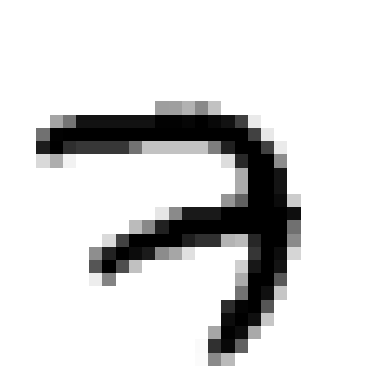

In [57]:
plt.imshow(x_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a class_names arr

In [58]:
y_train

array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8)

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [59]:
x_valid.shape

(5000, 28, 28)

Let's take a look at a sample of the images in the dataset:

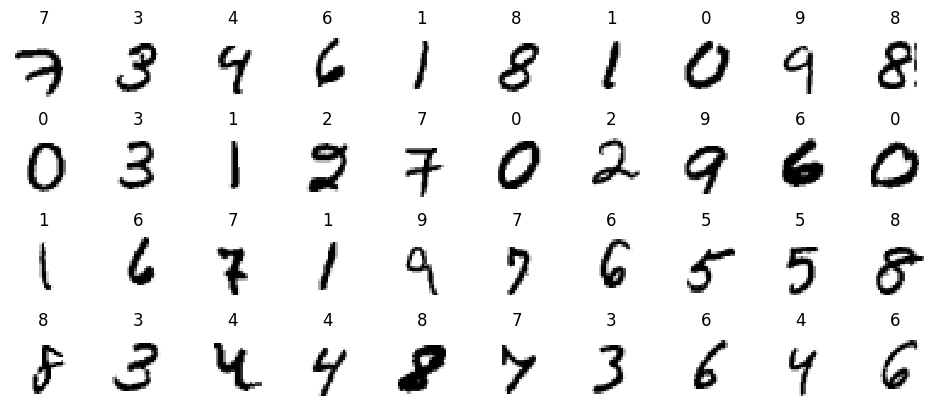

In [60]:
n_row = 4
n_col = 10
plt.figure(figsize=(n_col * 1.2, n_row * 1.2))
for row in range(n_row):
    for col in range(n_col):
        index = n_col * row + col
        plt.subplot(n_row, n_col, index + 1)
        plt.imshow(x_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [61]:
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs):
        lr = self.model.optimizer.learning_rate
        lr_value = float(tf.keras.backend.get_value(lr))
        self.rates.append(lr_value)
        self.losses.append(logs["loss"])
        lr.assign(lr_value * self.factor)

In [62]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [63]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [64]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer = keras.optimizers.SGD(learning_rate=1e-3),
             metrics=["accuracy"])
explon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [65]:
history = model.fit(x_train, y_train, epochs=1,
                   validation_data=(x_valid, y_valid),
                   callbacks=[explon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5849 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


We can now plot the loss as a function of the learning rate:

Text(0, 0.5, 'Loss')

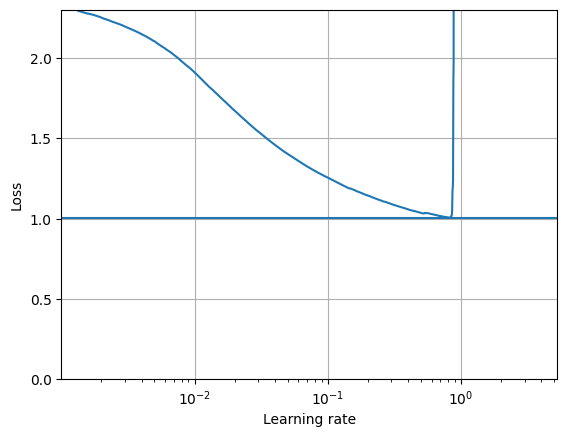

In [66]:
plt.plot(explon_lr.rates, explon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(explon_lr.losses), min(explon_lr.rates), max(explon_lr.rates))
plt.axis([min(explon_lr.rates), max(explon_lr.rates), 0, explon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [67]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [68]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [69]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=3e-1),
              metrics=["accuracy"])

In [70]:
run_index = 1 # increment this at every run
run_logdir = os.path.join(os.curdir, "my_mnist_logs", "run_{:03d}".format(run_index))
run_logdir

'.\\my_mnist_logs\\run_001'

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

history = model.fit(x_train, y_train, epochs=100,
                    validation_data=(x_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9263 - loss: 0.2337 - val_accuracy: 0.9736 - val_loss: 0.0965
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9713 - loss: 0.0930 - val_accuracy: 0.9722 - val_loss: 0.0925
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9813 - loss: 0.0606 - val_accuracy: 0.9754 - val_loss: 0.0900
Epoch 4/100
1426/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9870 - loss: 0.0441

In [ ]:
model = keras.models.load_model("my_mnist_model.keras") 
model.evaluate(x_test, y_test)

We got over 97% accuracy. Finally, let's look at the learning curves using TensorBoard:

In [ ]:
%tensorboard --logdir=./my_mnist_logs --port=6006